In [5]:
#1. Kütüphanelerin Yüklenmesi ve Hazırlık
#Veri analizi ve manipülasyonu için `pandas` ve `numpy`, metin işleme işlemleri için `re` kütüphanelerini yükledik.
#Ayrıca, her işlem adımında veri setindeki değişimi (satır sayısı, kayıp veri durumu) takip edebilmek için özel bir `raporla` fonksiyonu tanımladık.
#Tek seferde 30bin civarı veri temizledik. Tip ve birim değişikliklerini tamamladık, tarih saat işlemlerini gerçekleştirdik.

In [3]:
import pandas as pd
import numpy as np
import re

# --- RAPORLAMA FONKSİYONU ---
def raporla(adim, df_eski, df_yeni, mesaj):
    print(f"\n📢 {adim}")
    print("-" * 40)
    if df_eski is not None:
        print(f"   Önceki Satır: {len(df_eski)}")
    print(f"   Şimdiki Satır: {len(df_yeni)}")
    print(f"   📝 {mesaj}")
    print("-" * 40)

# ========================================================
# 1. VERİ YÜKLEME
# ========================================================
dosya_adi = "turkiye_hava_durumu_5sehir_FULL.csv" 
print("📂 Dosya yükleniyor...")
df = pd.read_csv(dosya_adi)

raporla("YÜKLEME", None, df, "Ham veri seti hafızaya alındı.")

# ========================================================
# 2. TEMİZLİK
# ========================================================
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['Time'])
df_clean = df_clean.drop_duplicates()

raporla("TEMİZLİK", df, df_clean, "Boş ve tekrar eden satırlar temizlendi.")

# ========================================================
# 3. TİP DÖNÜŞÜMÜ
# ========================================================
def sayi_al(text):
    if pd.isna(text): return np.nan
    text = str(text)
    match = re.search(r"[-+]?\d*\.\d+|\d+", text)
    return float(match.group()) if match else np.nan

cols = ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precip.']

print("🔄 Veriler sayıya çevriliyor...")
for col in cols:
    df_clean[col] = df_clean[col].apply(sayi_al)

# ========================================================
# 4. BİRİM DÖNÜŞÜMÜ
# ========================================================
print("🌍 Birimler dönüştürülüyor...")
df_clean['Sicaklik_C'] = (df_clean['Temperature'] - 32) * 5/9
df_clean['Nem_Yuzde'] = df_clean['Humidity']
df_clean['Ruzgar_kmh'] = df_clean['Wind Speed'] * 1.60934
df_clean['Basinc_hPa'] = df_clean['Pressure'] * 33.8639
df_clean['Yagis_mm'] = df_clean['Precip.'] * 25.4
df_clean['Hissedilen_C'] = (df_clean['Dew Point'] - 32) * 5/9 

df_final = df_clean.drop(columns=['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precip.'])

# ========================================================
# 5. TARİH VE SAAT İŞLEMLERİ
# ========================================================
print("⏰ Tarih formatı düzenleniyor...")
df_final['Tarih_Saat'] = pd.to_datetime(
    df_final['Tarih_Gun'] + ' ' + df_final['Time'],
    format='%Y-%m-%d %I:%M %p', 
    errors='coerce'
)
df_final = df_final.dropna(subset=['Tarih_Saat'])
df_final = df_final.set_index('Tarih_Saat').sort_index()

# ========================================================
# 6. SAATLİK DÜZENLEME VE EKSİK VERİ DOLDURMA
# ========================================================
print("📉 Veriler saat başlarına yuvarlanıyor (Resampling)...")

sayisal_df = df_final[['Sicaklik_C', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Yagis_mm', 'Hissedilen_C']]

# 1. Resampling Yap (Bu işlem olmayan saatler için NaN satırları yaratır)
df_resampled = df_final.groupby('Sehir')[sayisal_df.columns].resample('H').mean()

# --- EKSİK VERİ RAPORU (DOLDURMADAN ÖNCE) ---
eksik_once = df_resampled.isnull().sum().sum()
print(f"\n🔴 Doldurma Öncesi Toplam Eksik Veri Sayısı: {eksik_once}")
print("(Sebebi: Resampling işlemi, veri olmayan saatler için boş satırlar oluşturdu.)")

# 2. Eksikleri Doldur (Linear Interpolation)
# Bu yöntem, boşlukları bir önceki ve bir sonraki değerin ortalamasını alarak doldurur.
df_resampled = df_resampled.interpolate(method='linear')

# Kalan (baştaki/sondaki) boşlukları doldur
df_resampled = df_resampled.bfill().ffill()

# --- EKSİK VERİ RAPORU (DOLDURMADAN SONRA) ---
eksik_sonra = df_resampled.isnull().sum().sum()
print(f"\n🟢 Doldurma Sonrası Toplam Eksik Veri Sayısı: {eksik_sonra}")
print(f"✅ Kurtarılan/Doldurulan Veri Hücresi: {eksik_once - eksik_sonra}")

# İndeksi düzelt
df_resampled = df_resampled.reset_index()

raporla("BİTİŞ", df_clean, df_resampled, "Veri işlendi, saatlik hale getirildi ve boşluklar Interpolasyon ile dolduruldu.")

# Sonuçları Kaydet
df_resampled.to_csv('sicaklik_tahmin_verisi.csv', index=False)
print("\n💾 Hazır veri kaydedildi: 'sicaklik_tahmin_verisi.csv'")
print("\nÖrnek Veri:")
display(df_resampled.head())

📂 Dosya yükleniyor...

📢 YÜKLEME
----------------------------------------
   Şimdiki Satır: 206593
   📝 Ham veri seti hafızaya alındı.
----------------------------------------

📢 TEMİZLİK
----------------------------------------
   Önceki Satır: 206593
   Şimdiki Satır: 171543
   📝 Boş ve tekrar eden satırlar temizlendi.
----------------------------------------
🔄 Veriler sayıya çevriliyor...
🌍 Birimler dönüştürülüyor...
⏰ Tarih formatı düzenleniyor...
📉 Veriler saat başlarına yuvarlanıyor (Resampling)...

🔴 Doldurma Öncesi Toplam Eksik Veri Sayısı: 228
(Sebebi: Resampling işlemi, veri olmayan saatler için boş satırlar oluşturdu.)

🟢 Doldurma Sonrası Toplam Eksik Veri Sayısı: 0
✅ Kurtarılan/Doldurulan Veri Hücresi: 228

📢 BİTİŞ
----------------------------------------
   Önceki Satır: 171543
   Şimdiki Satır: 84120
   📝 Veri işlendi, saatlik hale getirildi ve boşluklar Interpolasyon ile dolduruldu.
----------------------------------------


C:\Users\Mert\AppData\Local\Temp\ipykernel_19188\4014604304.py:81: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_final.groupby('Sehir')[sayisal_df.columns].resample('H').mean()



💾 Hazır veri kaydedildi: 'sicaklik_tahmin_verisi.csv'

Örnek Veri:


,Sehir,Tarih_Saat,Sicaklik_C,Nem_Yuzde,Ruzgar_kmh,Basinc_hPa,Yagis_mm,Hissedilen_C
0,Adana,2024-01-01 00:00:00,10.000000,84.5,4.82802,1018.626112,0.0,7.500000
1,Adana,2024-01-01 01:00:00,8.888889,84.5,8.85137,1018.118154,0.0,6.666667
2,Adana,2024-01-01 02:00:00,9.444444,84.5,4.82802,1018.626112,0.0,6.944444
3,Adana,2024-01-01 03:00:00,8.333333,87.0,1.60934,1018.626112,0.0,6.666667
4,Adana,2024-01-01 04:00:00,8.888889,84.5,4.02335,1018.626112,0.0,6.666667


In [6]:
# 2. Temiz veri Setinin Yüklenmesi
#Temizlediğimiz veriyi grafiksel olarak çizdirdik.

📊 1. Sıcaklık Değişim Grafiği Çiziliyor...


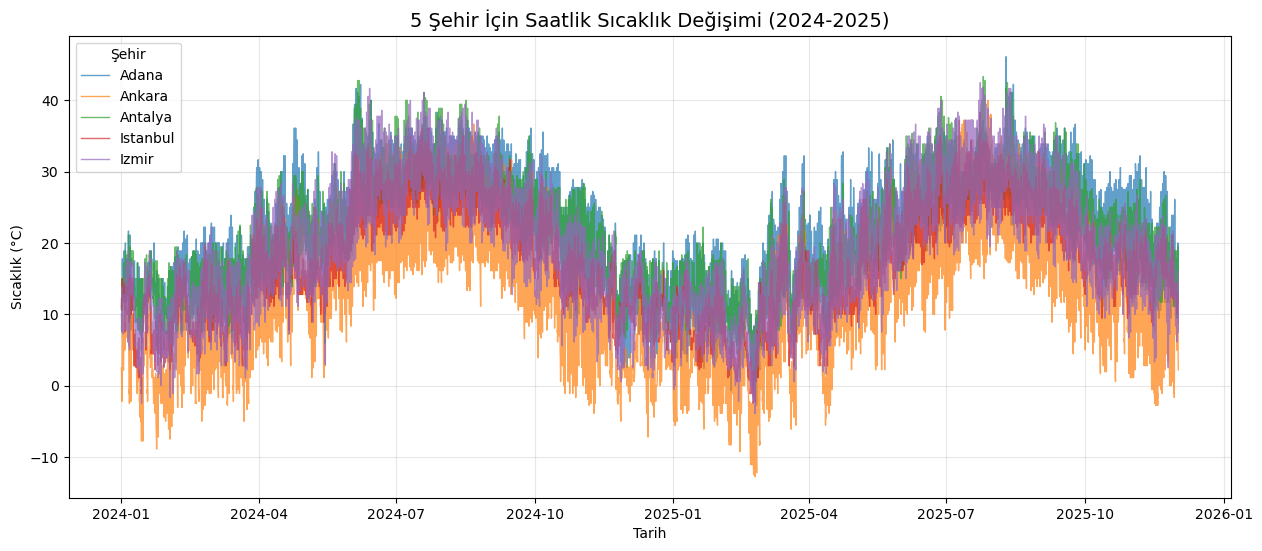

📊 2. Sıcaklık Dağılımı İnceleniyor...


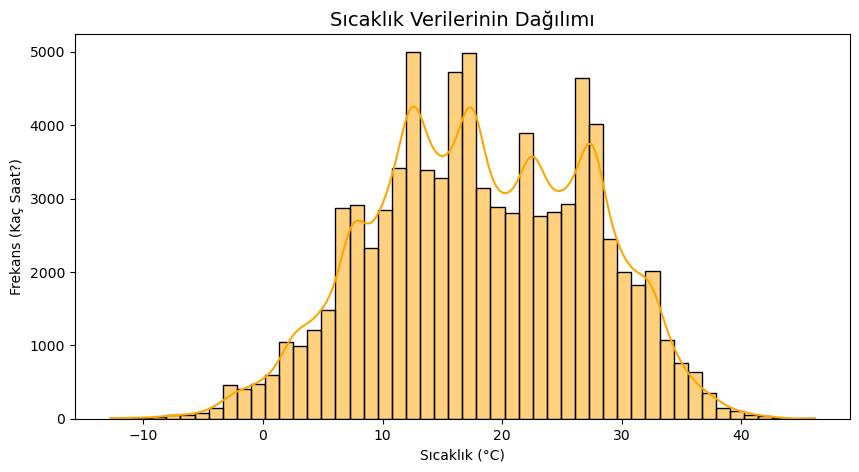

📊 3. İlişki Analizi (Korelasyon) Yapılıyor...


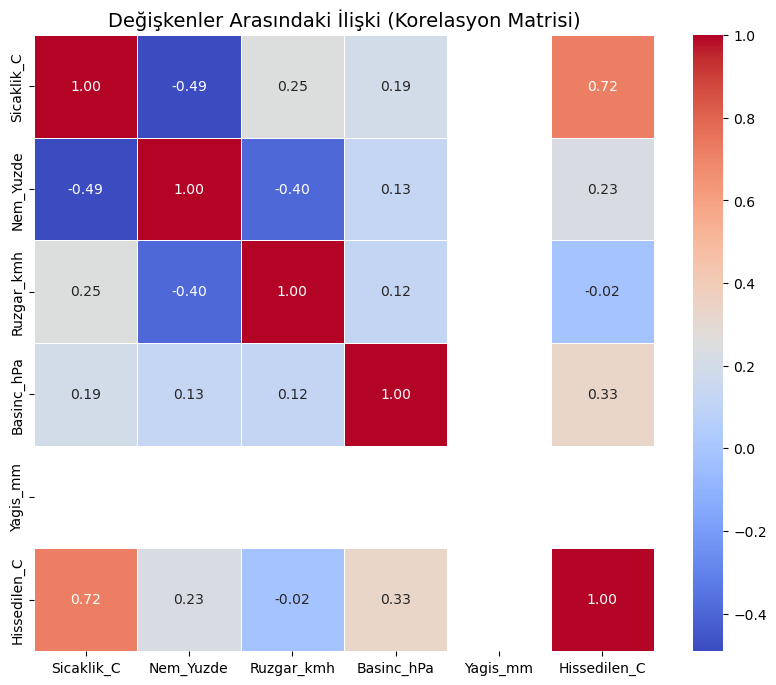

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hazır Veriyi Yükle
df = pd.read_csv('sicaklik_tahmin_verisi.csv')

# Tarihi datetime formatına çevirelim (Grafiklerin düzgün görünmesi için şart)
df['Tarih_Saat'] = pd.to_datetime(df['Tarih_Saat'])

# --- GRAFİK 1: ZAMAN SERİSİ (TREND) ---
print("📊 1. Sıcaklık Değişim Grafiği Çiziliyor...")
plt.figure(figsize=(15, 6))
# 'hue' parametresi ile her şehri farklı renk yapıyoruz
sns.lineplot(data=df, x='Tarih_Saat', y='Sicaklik_C', hue='Sehir', alpha=0.7, linewidth=1)

plt.title('5 Şehir İçin Saatlik Sıcaklık Değişimi (2024-2025)', fontsize=14)
plt.xlabel('Tarih')
plt.ylabel('Sıcaklık (°C)')
plt.legend(title='Şehir')
plt.grid(True, alpha=0.3)
plt.show()

# --- GRAFİK 2: DAĞILIM (HİSTOGRAM) ---
print("📊 2. Sıcaklık Dağılımı Histogram İle İnceleniyor...")
plt.figure(figsize=(10, 5))
sns.histplot(df['Sicaklik_C'], kde=True, bins=50, color='orange')

plt.title('Sıcaklık Verilerinin Dağılımı', fontsize=14)
plt.xlabel('Sıcaklık (°C)')
plt.ylabel('Frekans (Kaç Saat?)')
plt.show()

# --- GRAFİK 3: KORELASYON MATRİSİ (HEATMAP) ---
print("📊 3. İlişki Analizi (Korelasyon) Yapılıyor...")
plt.figure(figsize=(10, 8))

# Sadece sayısal sütunları seçelim (Şehir ve Tarih hariç)
sayisal_veri = df.select_dtypes(include=['float64', 'int64'])

# Korelasyonu hesapla
corr = sayisal_veri.corr()

# Isı haritasını çiz
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Değişkenler Arasındaki İlişki (Korelasyon Matrisi)', fontsize=14)
plt.show()

In [7]:
#Temizlediğimiz ham veriyi model oluşturmak için kullandım. Eğitim ve test verisi olarak 80'e 20 kullandım fakat çıktı olarak r2 skoru %97 çıktı. Pek doğru gibi değil.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# 1. Veriyi Hazırla
df_model = pd.read_csv('sicaklik_tahmin_verisi.csv')
df_model['Tarih_Saat'] = pd.to_datetime(df_model['Tarih_Saat'])

# --- ÖZNİTELİK MÜHENDİSLİĞİ (Tarihi Parçala) ---
# Model "Ocak ayı soğuktur", "Saat 14:00 sıcaktır" diyebilsin diye tarihi bölüyoruz.
df_model['Ay'] = df_model['Tarih_Saat'].dt.month
df_model['Gun'] = df_model['Tarih_Saat'].dt.day
df_model['Saat'] = df_model['Tarih_Saat'].dt.hour
df_model['Haftanin_Gunu'] = df_model['Tarih_Saat'].dt.dayofweek

# Şehir İsmini Sayıya Çevir (Label Encoding)
le = LabelEncoder()
df_model['Sehir_Kodu'] = le.fit_transform(df_model['Sehir'])

# 2. Girdiler (X) ve Hedef (y) Belirleme
# Hedefimiz: Sıcaklık (Sicaklik_C)
# Girdilerimiz: Diğer her şey (Nem, Rüzgar, Basınç, Ay, Saat, Şehir...)
X = df_model[['Sehir_Kodu', 'Ay', 'Gun', 'Saat', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Yagis_mm']]
y = df_model['Sicaklik_C']

# 3. Eğitim ve Test Olarak Bölme (%80 Eğitim - %20 Test)
# Hocanın notlarında geçen "Overfitting" riskini ölçmek için ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi   : {len(X_test)} satır")
print("-" * 40)

# --- MODELLERİ KUR VE EĞİT ---
modeller = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 hızı artırır
}

sonuclar = []

for isim, model in modeller.items():
    print(f"🤖 {isim} eğitiliyor...")
    model.fit(X_train, y_train) # İşte öğrenme anı!
    
    # Tahmin Yap
    y_pred = model.predict(X_test)
    
    # Başarıyı Ölç (Metrikler)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    sonuclar.append({
        "Model": isim,
        "MAE (Ortalama Hata)": mae,
        "RMSE (Karesel Hata)": rmse,
        "R2 Score (Başarı %)": r2 * 100
    })

# 4. SONUÇ TABLOSU
df_sonuc = pd.DataFrame(sonuclar)
df_sonuc = df_sonuc.sort_values(by='R2 Score (Başarı %)', ascending=False)

print("\n🏆 MODEL KARŞILAŞTIRMA TABLOSU:")
display(df_sonuc)

# En iyi modeli seç ve kaydet
en_iyi_model_ismi = df_sonuc.iloc[0]['Model']
print(f"\n✅ KAZANAN MODEL: {en_iyi_model_ismi}")

# Kazananı kaydet (Web sitesinde kullanmak için)
import joblib
best_model = modeller[en_iyi_model_ismi]
joblib.dump(best_model, 'hava_tahmin_modeli.pkl')
print("💾 Model dosyası 'hava_tahmin_modeli.pkl' olarak kaydedildi.")

Eğitim Verisi: 67296 satır
Test Verisi   : 16824 satır
----------------------------------------
🤖 Linear Regression eğitiliyor...
🤖 Decision Tree eğitiliyor...
🤖 Random Forest eğitiliyor...

🏆 MODEL KARŞILAŞTIRMA TABLOSU:


,Model,MAE (Ortalama Hata),RMSE (Karesel Hata),R2 Score (Başarı %)
2,Random Forest,0.952311,1.356983,97.698029
1,Decision Tree,1.265659,2.001072,94.994163
0,Linear Regression,5.706444,6.997594,38.786307



✅ KAZANAN MODEL: Random Forest
💾 Model dosyası 'hava_tahmin_modeli.pkl' olarak kaydedildi.


In [ ]:
#Burada eğitim ve test veri sayılarını değiştirdim. %97 sonucunu vermesi muhtemelen test verilerini karmaşık olarak seçmekten kaynaklanıyor.
#Bunu değiştirdim. Topladığım ve temizlediğim verilerden 2024 yılki tüm veriyi eğitim seti olarak kullandım,
#2025 yılı aralığa kadar olan kısmı test verisi olarak aldım. Bu şekilde eğittiğimde %83 olarak sonuç aldım. Test ettiğimde daha doğru sonuç çıktı.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Veriyi Tekrar Yükle (Garanti olsun)
df_model = pd.read_csv('sicaklik_tahmin_verisi.csv')
df_model['Tarih_Saat'] = pd.to_datetime(df_model['Tarih_Saat'])

# --- ÖZNİTELİK MÜHENDİSLİĞİ (Tekrar) ---
# Şehri sayıya çevir
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_model['Sehir_Kodu'] = le.fit_transform(df_model['Sehir'])

# Tarih parçalama
df_model['Ay'] = df_model['Tarih_Saat'].dt.month
df_model['Gun'] = df_model['Tarih_Saat'].dt.day
df_model['Saat'] = df_model['Tarih_Saat'].dt.hour

# 2. Girdiler (X) ve Hedef (y)
ozellikler = ['Sehir_Kodu', 'Ay', 'Gun', 'Saat', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Yagis_mm']
X = df_model[ozellikler]
y = df_model['Sicaklik_C']

# --- KRİTİK NOKTA: ZAMANA GÖRE BÖLME ---
# 2025'ten öncekiler EĞİTİM, sonrakiler TEST
# (Burada shuffle=False demeye gerek yok, elle bölüyoruz)

maske_2024 = df_model['Tarih_Saat'] < '2025-01-01'
maske_2025 = df_model['Tarih_Saat'] >= '2025-01-01'

X_train = X[maske_2024]
y_train = y[maske_2024]

X_test = X[maske_2025]
y_test = y[maske_2025]

print(f"Eğitim Seti (2024): {len(X_train)} satır")
print(f"Test Seti (2025)  : {len(X_test)} satır")
print("-" * 40)

# 3. Modeli Eğit (Sadece 2024'ü görerek)
print("🌲 Random Forest, 2024 verisiyle eğitiliyor...")
rf_model_real = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_real.fit(X_train, y_train)

# 4. Sınav Yap (2025 verisiyle)
print("🔮 2025 yılı tahmin ediliyor...")
y_pred = rf_model_real.predict(X_test)

# 5. Sonuçlar
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n🏆 GERÇEKÇİ SENARYO SONUÇLARI:")
print(f"R2 Score (Başarı): %{r2 * 100:.2f}")
print(f"MAE (Hata Payı)  : {mae:.2f} Derece")

# Farkı görelim
print("\n--- YORUM ---")
if r2 > 0.90:
    print("Mükemmel! Modelin 2024'ten öğrendikleriyle 2025'i harika tahmin etti.")
else:
    print("Başarı biraz düştü (Normaldir). Çünkü model 2025'in iklimini hiç görmemişti.")

Eğitim Seti (2024): 43920 satır
Test Seti (2025)  : 40200 satır
----------------------------------------
🌲 Random Forest, 2024 verisiyle eğitiliyor...
🔮 2025 yılı tahmin ediliyor...

🏆 GERÇEKÇİ SENARYO SONUÇLARI:
R2 Score (Başarı): %83.07
MAE (Hata Payı)  : 2.81 Derece

--- YORUM ---
Başarı biraz düştü (Normaldir). Çünkü model 2025'in iklimini hiç görmemişti.


In [8]:
#Eğittiğim modeli final_model.pkl dosya olarak kaydediyorum.

In [7]:
import joblib

joblib.dump(rf_model_real, 'final_model.pkl')

print("💾 Başarılı! %83 Başarılı Gerçekçi Model 'final_model.pkl' olarak kaydedildi.")
print("Bu dosyayı Web Sitesi (Flask) kısmında kullanacağız.")

💾 Başarılı! %83 Başarılı Gerçekçi Model 'final_model.pkl' olarak kaydedildi.
Bu dosyayı Web Sitesi (Flask) kısmında kullanacağız.


In [9]:
#Burada eğittiğim modeli kullanarak bir test gerçekleştiriyorum

In [10]:
import joblib
import pandas as pd
import numpy as np

# 1. Modeli Yükle
model = joblib.load('final_model.pkl')
print("✅ Model yüklendi ve tahmine hazır!")

# --- TEST ETMEK İSTEDİĞİN DEĞERLERİ BURAYA GİR ---
# Senaryo: 9 Aralık 2025, Saat 14:00, İstanbul

sehir_kodu = 3  # 2: Istanbul (Alfabetik sıraya göre: 0:Adana, 1:Ankara, 2:Antalya, 3:Istanbul, 4:Izmir - KONTROL ET!)
# Not: LabelEncoder sıralaması önemlidir. Şehirlerin alfabetik sırasına göre:
# Adana=0, Ankara=1, Antalya=2, Istanbul=3, Izmir=4 (Bunu aşağıda kontrol edeceğiz)

ay = 12
gun = 9
saat = 16
nem = 77.0       # %
ruzgar = 10.0    # km/h
basinc = 1023.7  # hPa
yagis = 0.0      # mm

# 2. Girdileri Modele Uygun Hale Getir
# Model eğitimde şu sırayı kullandı: ['Sehir_Kodu', 'Ay', 'Gun', 'Saat', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Yagis_mm']
girdi_verisi = np.array([[sehir_kodu, ay, gun, saat, nem, ruzgar, basinc, yagis]])

# 3. Tahmin Yap
tahmin = model.predict(girdi_verisi)

print("-" * 40)
print(f"🌍 Şehir Kodu: {sehir_kodu}")
print(f"📅 Tarih     : {gun}.{ay}.2025 Saat {saat}:00")
print(f"💨 Koşullar  : Nem %{nem}, Rüzgar {ruzgar} km/h")
print("-" * 40)
print(f"🌡️ MODELİN TAHMİNİ: {tahmin[0]:.2f} °C")
print("-" * 40)

✅ Model yüklendi ve tahmine hazır!
----------------------------------------
🌍 Şehir Kodu: 3
📅 Tarih     : 9.12.2025 Saat 16:00
💨 Koşullar  : Nem %77.0, Rüzgar 10.0 km/h
----------------------------------------
🌡️ MODELİN TAHMİNİ: 13.18 °C
----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [10]:
#Temizlediğimi sandığım veride bir açıklık olduğunu fark ettim. Yağış ile ilgili tüm veriler 0.0, yani hiçbir yağış verisi yok.

In [2]:
import pandas as pd

# 1. Ham Dosyayı Oku (İşlenmemiş halini)
df_raw = pd.read_csv('turkiye_hava_durumu_5sehir_FULL.csv')

# 2. 'Precip.' Sütununa Bak
print("--- Yağış Verisi İncelemesi ---")
print(f"Toplam Satır Sayısı: {len(df_raw)}")

# Benzersiz değerleri göster (Sadece 0.0 in mi var?)
print("\nBenzersiz Yağış Değerleri (İlk 20):")
print(df_raw['Precip.'].unique()[:20])

# 3. 0.0 Olmayan Satır Sayısı
# (Sadece rakamları alıp kontrol edelim)
df_raw['Yagis_Sayisal'] = df_raw['Precip.'].astype(str).str.extract(r'(\d+\.\d+)').astype(float)
yagisli_saatler = df_raw[df_raw['Yagis_Sayisal'] > 0.0]

print(f"\nYağış Görülen (0.0'dan büyük) Satır Sayısı: {len(yagisli_saatler)}")

if len(yagisli_saatler) > 0:
    print("\nÖrnek Yağışlı Günler:")
    display(yagisli_saatler[['Tarih_Gun', 'Time', 'Sehir', 'Precip.', 'Condition']].head())
else:
    print("\n⚠️ HİÇ YAĞIŞ VERİSİ YOK! Hepsi 0.0 görünüyor.")

--- Yağış Verisi İncelemesi ---
Toplam Satır Sayısı: 206593

Benzersiz Yağış Değerleri (İlk 20):
['0.0\xa0°in' nan]

Yağış Görülen (0.0'dan büyük) Satır Sayısı: 0

⚠️ HİÇ YAĞIŞ VERİSİ YOK! Hepsi 0.0 görünüyor.


In [12]:
#Yağış verisini eklerken ham verideki Condition sütununu ele aldım. 
#Özetle bu sütundaki light rain, heavy snow, thunder isimli verileri yağış var olarak (yani 1.0) partly cloud, clear isimli
#verileri de yağış yok olarak (yani 0.0) olarak ekledim.

In [3]:
import pandas as pd
import numpy as np
import re

# --- RAPORLAMA FONKSİYONU ---
def raporla(adim, mesaj):
    print(f"\n📢 {adim}")
    print("-" * 40)
    print(f"   📝 {mesaj}")
    print("-" * 40)

# ========================================================
# 1. VERİ YÜKLEME
# ========================================================
dosya_adi = "turkiye_hava_durumu_5sehir_FULL.csv"
print("📂 Dosya yükleniyor...")
df = pd.read_csv(dosya_adi)

# ========================================================
# 2. KRİTİK HAMLE: TEXT MINING (Yazıdan Veri Çıkarma)
# ========================================================
# Yağış miktarı (0.0) bozuk olduğu için, 'Condition' sütununa bakıyoruz.
# İçinde yağış ifade eden kelimeler varsa 1, yoksa 0 basacağız.
print("⛈️ 'Condition' sütunundan yağış bilgisi kurtarılıyor...")

yagis_kelimeleri = 'Rain|Shower|Snow|Drizzle|Thunder|Storm|Hail'
# Case=False (Büyük küçük harf duyarsız)
df['Yagis_Var_Mi'] = df['Condition'].str.contains(yagis_kelimeleri, case=False, na=False).astype(int)

raporla("VERİ KURTARMA", f"Condition sütunu tarandı. {df['Yagis_Var_Mi'].sum()} saatlik yağışlı veri tespit edildi.")

# ========================================================
# 3. TEMİZLİK VE TİP DÖNÜŞÜMÜ
# ========================================================
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['Time'])
df_clean = df_clean.drop_duplicates()

def sayi_al(text):
    if pd.isna(text): return np.nan
    text = str(text)
    match = re.search(r"[-+]?\d*\.\d+|\d+", text)
    return float(match.group()) if match else np.nan

cols = ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Pressure'] # Precip'i çıkardık, işe yaramıyor
print("🔄 Sayısal veriler temizleniyor...")
for col in cols:
    df_clean[col] = df_clean[col].apply(sayi_al)

# ========================================================
# 4. BİRİM DÖNÜŞÜMÜ (Feature Engineering)
# ========================================================
print("🌍 Birimler dönüştürülüyor (Metric Sisteme)...")

df_clean['Sicaklik_C'] = (df_clean['Temperature'] - 32) * 5/9
df_clean['Nem_Yuzde'] = df_clean['Humidity']
df_clean['Ruzgar_kmh'] = df_clean['Wind Speed'] * 1.60934
df_clean['Basinc_hPa'] = df_clean['Pressure'] * 33.8639
# Hissedilen sıcaklık (Çiy noktası bazlı basit hesap)
df_clean['Hissedilen_C'] = (df_clean['Dew Point'] - 32) * 5/9 

# Eski sütunları atalım
df_final = df_clean.drop(columns=['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precip.', 'Condition'])

# ========================================================
# 5. ZAMAN DÜZENLEMESİ
# ========================================================
print("⏰ Zaman serisi oluşturuluyor...")
df_final['Zaman_Damgasi'] = pd.to_datetime(
    df_final['Tarih_Gun'] + ' ' + df_final['Time'], 
    format='%Y-%m-%d %I:%M %p', 
    errors='coerce'
)
df_final = df_final.dropna(subset=['Zaman_Damgasi']).set_index('Zaman_Damgasi').sort_index()

# ========================================================
# 6. RESAMPLING (SAATLİK DÜZENLEME)
# ========================================================
print("📉 Veriler saatlik hale getiriliyor...")

# Sayısal verilerin ortalamasını al
sayisal_cols = ['Sicaklik_C', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Hissedilen_C']
df_resampled = df_final.groupby('Sehir')[sayisal_cols].resample('H').mean()

# Yağış verisi (0 veya 1) için ortalama almak yerine 'max' alalım.
# Yani o saat içinde 1 kere bile yağmur yağdıysa, o saat yağmurludur (1).
df_yagis = df_final.groupby('Sehir')['Yagis_Var_Mi'].resample('H').max()

# İkisini birleştir
df_resampled = pd.concat([df_resampled, df_yagis], axis=1)

# ========================================================
# 7. EKSİK VERİ DOLDURMA (IMPUTATION)
# ========================================================
print("fill Eksik veriler dolduruluyor...")

# Sayısal verileri Linear Interpolation ile doldur (Sıcaklık yavaş değişir)
df_resampled[sayisal_cols] = df_resampled[sayisal_cols].interpolate(method='linear')

# Yağış verisini (0/1) en yakın komşuyla doldur (Nearest) veya 0 bas
df_resampled['Yagis_Var_Mi'] = df_resampled['Yagis_Var_Mi'].fillna(0) # Bilmiyorsak yağmıyor varsayalım

# İndeksi düzelt
df_resampled = df_resampled.reset_index()

# Şehir boşluklarını doldur (Forward Fill)
df_resampled['Sehir'] = df_resampled['Sehir'].ffill()

raporla("BİTİŞ", "İşlem tamamlandı. 'Yagis_Var_Mi' sütunu başarıyla oluşturuldu.")

# Sonuçları Kaydet
df_resampled.to_csv('sicaklik_tahmin_verisi.csv', index=False)
print("\n💾 Yeni ve Akıllı Veri Seti Kaydedildi: 'sicaklik_tahmin_verisi.csv'")
print("\nÖrnek Veri (Yağışlı Saatlere Bakalım):")
# Sadece yağış olan satırlardan örnek göster
print(df_resampled[df_resampled['Yagis_Var_Mi'] == 1].head())

📂 Dosya yükleniyor...
⛈️ 'Condition' sütunundan yağış bilgisi kurtarılıyor...

📢 VERİ KURTARMA
----------------------------------------
   📝 Condition sütunu tarandı. 9960 saatlik yağışlı veri tespit edildi.
----------------------------------------
🔄 Sayısal veriler temizleniyor...
🌍 Birimler dönüştürülüyor (Metric Sisteme)...
⏰ Zaman serisi oluşturuluyor...
📉 Veriler saatlik hale getiriliyor...
fill Eksik veriler dolduruluyor...

📢 BİTİŞ
----------------------------------------
   📝 İşlem tamamlandı. 'Yagis_Var_Mi' sütunu başarıyla oluşturuldu.
----------------------------------------


C:\Users\Mert\AppData\Local\Temp\ipykernel_6708\2741409003.py:83: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_final.groupby('Sehir')[sayisal_cols].resample('H').mean()
C:\Users\Mert\AppData\Local\Temp\ipykernel_6708\2741409003.py:87: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_yagis = df_final.groupby('Sehir')['Yagis_Var_Mi'].resample('H').max()



💾 Yeni ve Akıllı Veri Seti Kaydedildi: 'sicaklik_tahmin_verisi.csv'

Örnek Veri (Yağışlı Saatlere Bakalım):
    Sehir       Zaman_Damgasi  Sicaklik_C  Nem_Yuzde  Ruzgar_kmh   Basinc_hPa  \
90  Adana 2024-01-04 18:00:00   17.222222       79.5     6.43736  1011.514693   
91  Adana 2024-01-04 19:00:00   16.111111       88.0     3.21868  1011.514693   
92  Adana 2024-01-04 20:00:00   15.000000       94.0     4.02335  1011.514693   
93  Adana 2024-01-04 21:00:00   15.000000       94.0     3.21868  1011.514693   
94  Adana 2024-01-04 22:00:00   15.000000       94.0     1.60934  1011.514693   

    Hissedilen_C  Yagis_Var_Mi  
90     13.333333           1.0  
91     13.888889           1.0  
92     13.888889           1.0  
93     13.888889           1.0  
94     13.888889           1.0  


In [13]:
#Başka bir sorun var mı diye verileri kontrol ediyorum

In [5]:
import pandas as pd

# 1. Temizlenmiş ve Kaydedilmiş Veriyi Oku
df = pd.read_csv('sicaklik_tahmin_verisi.csv')

# 2. İlk 5 Satırı Göster (Başı Düzgün mü?)
print("--- 🔼 İLK 5 SATIR (Başlangıç Tarihine Bak) ---")
display(df.head())

# 3. Son 5 Satırı Göster (Sonu Düzgün mü?)
print("\n--- 🔽 SON 5 SATIR (Bitiş Tarihine Bak) ---")
display(df.tail())

# 4. Rastgele 5 Satır Getir (Arada sürpriz var mı?)
print("\n--- 🎲 RASTGELE 50 SATIR (Örneklem) ---")
display(df.sample(50))

--- 🔼 İLK 5 SATIR (Başlangıç Tarihine Bak) ---


,Sehir,Zaman_Damgasi,Sicaklik_C,Nem_Yuzde,Ruzgar_kmh,Basinc_hPa,Hissedilen_C,Yagis_Var_Mi
0,Adana,2024-01-01 00:00:00,10.000000,84.5,4.82802,1018.626112,7.500000,0.0
1,Adana,2024-01-01 01:00:00,8.888889,84.5,8.85137,1018.118153,6.666667,0.0
2,Adana,2024-01-01 02:00:00,9.444444,84.5,4.82802,1018.626112,6.944444,0.0
3,Adana,2024-01-01 03:00:00,8.333333,87.0,1.60934,1018.626112,6.666667,0.0
4,Adana,2024-01-01 04:00:00,8.888889,84.5,4.02335,1018.626112,6.666667,0.0



--- 🔽 SON 5 SATIR (Bitiş Tarihine Bak) ---


,Sehir,Zaman_Damgasi,Sicaklik_C,Nem_Yuzde,Ruzgar_kmh,Basinc_hPa,Hissedilen_C,Yagis_Var_Mi
84115,Izmir,2025-12-01 19:00:00,10.000000,87.0,1.60934,1004.741913,7.777778,0.0
84116,Izmir,2025-12-01 20:00:00,8.888889,93.0,5.63269,1004.741913,7.777778,0.0
84117,Izmir,2025-12-01 21:00:00,8.333333,90.0,4.82802,1005.757830,7.222222,0.0
84118,Izmir,2025-12-01 22:00:00,7.500000,93.0,3.21868,1005.757830,6.666667,0.0
84119,Izmir,2025-12-01 23:00:00,7.500000,93.0,0.80467,1005.757830,6.666667,0.0



--- 🎲 RASTGELE 5 SATIR (Örneklem) ---


,Sehir,Zaman_Damgasi,Sicaklik_C,Nem_Yuzde,Ruzgar_kmh,Basinc_hPa,Hissedilen_C,Yagis_Var_Mi
48316,Antalya,2025-09-03 04:00:00,25.000000,89.000000,0.000000,995.937299,22.777778,0.0
30423,Ankara,2025-07-20 15:00:00,31.111111,23.500000,13.679390,901.118379,8.055556,0.0
72284,Izmir,2024-07-26 20:00:00,28.333333,43.500000,30.577460,992.381590,15.000000,0.0
75661,Izmir,2024-12-14 13:00:00,11.111111,45.500000,22.530760,1012.361290,-0.555556,0.0
6320,Adana,2024-09-20 08:00:00,24.444444,71.000000,8.046700,1007.451025,18.888889,0.0
77842,Izmir,2025-03-15 10:00:00,19.444444,56.000000,7.242030,1005.757830,10.555556,0.0
49481,Antalya,2025-10-21 17:00:00,21.851852,67.000000,9.656040,1008.466942,15.370370,1.0
47381,Antalya,2025-07-26 05:00:00,32.222222,26.000000,20.116750,994.921382,10.000000,0.0
31804,Ankara,2025-09-16 04:00:00,14.444444,57.000000,3.218680,908.229798,6.111111,0.0
51709,Istanbul,2024-02-21 13:00:00,10.000000,64.000000,11.265380,1018.964751,3.333333,0.0


In [14]:
#Yeni eklediğimiz yağış verileriyle modeli tekrar eğitiyorum

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import joblib

# 1. Hazır Veriyi Yükle
print("📂 Veri yükleniyor...")
df_model = pd.read_csv('sicaklik_tahmin_verisi.csv')
df_model['Zaman_Damgasi'] = pd.to_datetime(df_model['Zaman_Damgasi'])

# 2. Öznitelik Mühendisliği (Tarihi Parçala)
# Model "Ocak ayı soğuktur" diyebilsin diye tarihi bölüyoruz
df_model['Ay'] = df_model['Zaman_Damgasi'].dt.month
df_model['Gun'] = df_model['Zaman_Damgasi'].dt.day
df_model['Saat'] = df_model['Zaman_Damgasi'].dt.hour

# Şehir İsmini Sayıya Çevir (Label Encoding)
# Adana->0, Ankara->1 gibi
le = LabelEncoder()
df_model['Sehir_Kodu'] = le.fit_transform(df_model['Sehir'])

# Şehir kodlarını ekrana yazalım (API yazarken lazım olacak)
print("\n🏙️ Şehir Kodları:")
for i, sehir in enumerate(le.classes_):
    print(f"   {sehir}: {i}")

# 3. Girdiler (X) ve Hedef (y)
# Hedefimiz: Sıcaklık (Sicaklik_C)
ozellikler = ['Sehir_Kodu', 'Ay', 'Gun', 'Saat', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Yagis_Var_Mi']
X = df_model[ozellikler]
y = df_model['Sicaklik_C']

# 4. ZAMANA GÖRE BÖLME (Train: 2024, Test: 2025)
print("\n✂️ Veri Zamana Göre Bölünüyor...")
maske_2024 = df_model['Zaman_Damgasi'] < '2025-01-01'
maske_2025 = df_model['Zaman_Damgasi'] >= '2025-01-01'

X_train = X[maske_2024]
y_train = y[maske_2024]
X_test = X[maske_2025]
y_test = y[maske_2025]

print(f"   Eğitim Seti (2024): {len(X_train)} satır")
print(f"   Test Seti (2025)  : {len(X_test)} satır")

# 5. MODELLERİ YARIŞTIRMA
modeller = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
}

sonuclar = []

print("\n🏁 YARIŞ BAŞLADI (Modeller Eğitiliyor)...")
for isim, model in modeller.items():
    # Eğit
    model.fit(X_train, y_train)
    
    # Test Et (2025 verisiyle)
    y_pred = model.predict(X_test)
    
    # Puanla
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred) * 100
    
    print(f"   🤖 {isim} tamamlandı. (R2: %{r2:.2f})")
    
    sonuclar.append({
        "Model": isim,
        "MAE (Hata)": mae,
        "R2 Score (%)": r2
    })

# 6. SONUÇ TABLOSU
df_sonuc = pd.DataFrame(sonuclar).sort_values(by='R2 Score (%)', ascending=False)
print("\n🏆 MAÇ SONUCU:")
display(df_sonuc)

# 7. ŞAMPİYONU KAYDET
en_iyi_model_ismi = df_sonuc.iloc[0]['Model']
best_model = modeller[en_iyi_model_ismi]

joblib.dump(best_model, 'final_model.pkl')
print(f"\n💾 Şampiyon Model ({en_iyi_model_ismi}) 'final_model.pkl' olarak kaydedildi.")

📂 Veri yükleniyor...

🏙️ Şehir Kodları:
   Adana: 0
   Ankara: 1
   Antalya: 2
   Istanbul: 3
   Izmir: 4

✂️ Veri Zamana Göre Bölünüyor...
   Eğitim Seti (2024): 43920 satır
   Test Seti (2025)  : 40200 satır

🏁 YARIŞ BAŞLADI (Modeller Eğitiliyor)...
   🤖 Linear Regression tamamlandı. (R2: %39.10)
   🤖 Decision Tree tamamlandı. (R2: %79.07)
   🤖 Random Forest tamamlandı. (R2: %83.11)

🏆 MAÇ SONUCU:


,Model,MAE (Hata),R2 Score (%)
2,Random Forest,2.809493,83.106870
1,Decision Tree,3.119947,79.068717
0,Linear Regression,5.591688,39.100436



💾 Şampiyon Model (Random Forest) 'final_model.pkl' olarak kaydedildi.


In [15]:
#Tekrar test ediyorum bu sefer sonuç daha doğru çıkıyor

In [7]:
import joblib
import pandas as pd
import numpy as np

# 1. Modeli Yükle
model = joblib.load('final_model.pkl')
print("✅ Model yüklendi ve tahmine hazır!")

# --- TEST ETMEK İSTEDİĞİN DEĞERLERİ BURAYA GİR ---
# Senaryo: 9 Aralık 2025, Saat 14:00, İstanbul
# (Bu değerleri o anki hava durumu sitesinden bakıp girebilirsin)

sehir_kodu = 3  # 2: Istanbul (Alfabetik sıraya göre: 0:Adana, 1:Ankara, 2:Antalya, 3:Istanbul, 4:Izmir - KONTROL ET!)
# Not: LabelEncoder sıralaması önemlidir. Şehirlerin alfabetik sırasına göre:
# Adana=0, Ankara=1, Antalya=2, Istanbul=3, Izmir=4 (Bunu aşağıda kontrol edeceğiz)

ay = 12
gun = 9
saat = 16
nem = 77.0       # %
ruzgar = 10.0    # km/h
basinc = 1023.7  # hPa
yagis = 0.0      # mm

# 2. Girdileri Modele Uygun Hale Getir
# Model eğitimde şu sırayı kullandı: ['Sehir_Kodu', 'Ay', 'Gun', 'Saat', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Yagis_mm']
girdi_verisi = np.array([[sehir_kodu, ay, gun, saat, nem, ruzgar, basinc, yagis]])

# 3. Tahmin Yap
tahmin = model.predict(girdi_verisi)

print("-" * 40)
print(f"🌍 Şehir Kodu: {sehir_kodu}")
print(f"📅 Tarih     : {gun}.{ay}.2025 Saat {saat}:00")
print(f"💨 Koşullar  : Nem %{nem}, Rüzgar {ruzgar} km/h")
print("-" * 40)
print(f"🌡️ MODELİN TAHMİNİ: {tahmin[0]:.2f} °C")
print("-" * 40)

✅ Model yüklendi ve tahmine hazır!
----------------------------------------
🌍 Şehir Kodu: 3
📅 Tarih     : 9.12.2025 Saat 16:00
💨 Koşullar  : Nem %77.0, Rüzgar 10.0 km/h
----------------------------------------
🌡️ MODELİN TAHMİNİ: 13.02 °C
----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [16]:
#Eksik ya da aykırı değer var mı diye tekrar kontrol ediyorum

📂 'sicaklik_tahmin_verisi.csv' dosyası yükleniyor...

--- 1. EKSİK VERİ KONTROLÜ ---
✅ MÜKEMMEL! Hiç boş (NaN) veri kalmamış.

--- 2. 'ÖLÜ' (Hep 0) SÜTUN KONTROLÜ ---
✅ Temiz. Sürekli 0 olan anlamsız bir sütun yok.

--- 3. MANTIK KONTROLÜ (Min/Max Değerler) ---


,Sicaklik_C,Nem_Yuzde,Ruzgar_kmh,Basinc_hPa
min,-12.777778,7.0,0.00000,507.450541
max,46.111111,100.0,61.95959,1031.833033


✅ Sıcaklık değerleri mantıklı aralıkta (-30 ile +50 arası).


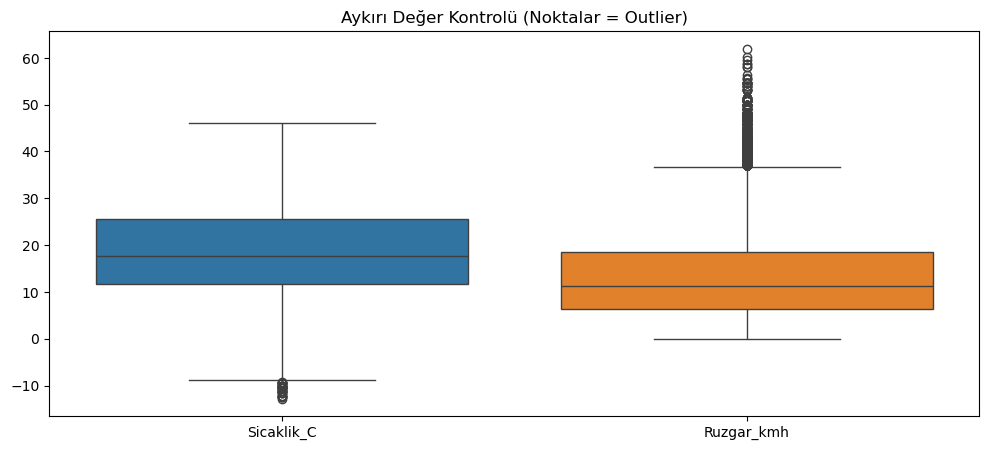

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hazır Veriyi Yükle
print("📂 'sicaklik_tahmin_verisi.csv' dosyası yükleniyor...")
df = pd.read_csv('sicaklik_tahmin_verisi.csv')

# --- KONTROL 1: BOŞ VERİLER (MISSING VALUES) ---
print("\n--- 1. EKSİK VERİ KONTROLÜ ---")
boslar = df.isnull().sum()
if boslar.sum() == 0:
    print("✅ MÜKEMMEL! Hiç boş (NaN) veri kalmamış.")
else:
    print("❌ DİKKAT! Hala boş veriler var:")
    print(boslar[boslar > 0])

# --- KONTROL 2: SÜREKLİ 0 OLAN SÜTUNLAR (DEAD FEATURES) ---
print("\n--- 2. 'ÖLÜ' (Hep 0) SÜTUN KONTROLÜ ---")
olu_sutunlar = []
for col in df.select_dtypes(include=[np.number]).columns:
    if (df[col] == 0).all():
        olu_sutunlar.append(col)

if len(olu_sutunlar) == 0:
    print("✅ Temiz. Sürekli 0 olan anlamsız bir sütun yok.")
else:
    print(f"⚠️ UYARI: Şu sütunlar tamamen 0 dolu (Gereksiz olabilir): {olu_sutunlar}")

# --- KONTROL 3: MANTIKSIZ/AYKIRI DEĞERLER (OUTLIERS) ---
print("\n--- 3. MANTIK KONTROLÜ (Min/Max Değerler) ---")
# Sıcaklık, Rüzgar vb. için min/max değerlerine bakalım
ozet = df[['Sicaklik_C', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa']].describe().loc[['min', 'max']]
display(ozet)

# Yorumlayalım
min_temp = ozet.loc['min', 'Sicaklik_C']
max_temp = ozet.loc['max', 'Sicaklik_C']

if min_temp < -30 or max_temp > 50:
    print("❌ HATA: Sıcaklık verisinde saçma değerler var (-30'dan küçük veya 50'den büyük). Birim hatası olabilir.")
else:
    print("✅ Sıcaklık değerleri mantıklı aralıkta (-30 ile +50 arası).")

# Kutu Grafiği (Boxplot) ile Aykırı Değerleri Gözle Görelim
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[['Sicaklik_C', 'Ruzgar_kmh']])
plt.title('Aykırı Değer Kontrolü (Noktalar = Outlier)')
plt.show()

In [5]:
#Son kontrolleri yapıyorum

In [1]:
import pandas as pd
import numpy as np

# 1. Dosyayı Yükle
print("📂 Veri dosyası inceleniyor...")
df = pd.read_csv('sicaklik_tahmin_verisi.csv')

print(f"📊 Toplam Satır Sayısı: {len(df)}")
print("-" * 40)

# --- KONTROL 1: BOŞ VERİLER (NULL CHECK) ---
bos_var_mi = df.isnull().sum().sum()
if bos_var_mi == 0:
    print("✅ 1. Boş Veri (NaN): TEMİZ! Hiç boş hücre yok.")
else:
    print("❌ 1. Boş Veri (NaN): DİKKAT! Şu sütunlarda boşluklar var:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

# --- KONTROL 2: MANTIKSIZ SIFIRLAR (ZERO CHECK) ---
# Sıcaklık 0 olabilir, Yağış 0 olabilir ama Basınç ve Nem 0 olamaz!
hatali_basinc = len(df[df['Basinc_hPa'] < 800]) # 800 hPa altı genelde hatadır (Fırtınada bile 950 olur)
hatali_nem = len(df[df['Nem_Yuzde'] == 0])

if hatali_basinc == 0 and hatali_nem == 0:
    print("✅ 2. Mantıksız Değerler: TEMİZ! Basınç ve Nem değerleri normal.")
else:
    print(f"⚠️ 2. Mantıksız Değerler: UYARI!")
    if hatali_basinc > 0: print(f"   - {hatali_basinc} satırda Basınç çok düşük (<800 hPa).")
    if hatali_nem > 0: print(f"   - {hatali_nem} satırda Nem %0 görünüyor (Hata olabilir).")

# --- KONTROL 3: VERİ TİPLERİ ---
print("-" * 40)
print("ℹ️ Veri Tipleri:")
print(df.dtypes)

# --- KONTROL 4: İSTATİSTİKSEL ÖZET ---
print("-" * 40)
print("📈 İstatistiksel Özet (Min/Max Değerlere Bak):")
display(df.describe()[['Sicaklik_C', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa']])

print("\n🚀 SONUÇ:")
if bos_var_mi == 0 and hatali_basinc == 0:
    print("Veri seti %100 SAĞLIKLI ve Modele Girmeye Hazır! ✅")
else:
    print("Veride ufak pürüzler var, yukarıdaki uyarılara bakmalısın.")

📂 Veri dosyası inceleniyor...
📊 Toplam Satır Sayısı: 84120
----------------------------------------
✅ 1. Boş Veri (NaN): TEMİZ! Hiç boş hücre yok.
⚠️ 2. Mantıksız Değerler: UYARI!
   - 3 satırda Basınç çok düşük (<800 hPa).
----------------------------------------
ℹ️ Veri Tipleri:
Sehir             object
Zaman_Damgasi     object
Sicaklik_C       float64
Nem_Yuzde        float64
Ruzgar_kmh       float64
Basinc_hPa       float64
Hissedilen_C     float64
Yagis_Var_Mi     float64
dtype: object
----------------------------------------
📈 İstatistiksel Özet (Min/Max Değerlere Bak):


,Sicaklik_C,Nem_Yuzde,Ruzgar_kmh,Basinc_hPa
count,84120.000000,84120.000000,84120.000000,84120.000000
mean,18.238442,62.819154,13.127783,986.471573
std,8.990060,21.166132,8.919582,40.500541
min,-12.777778,7.000000,0.000000,507.450541
25%,11.666667,47.000000,6.437360,993.905465
50%,17.777778,65.000000,11.265380,1003.725996
75%,25.555556,79.500000,18.507410,1009.821498
max,46.111111,100.000000,61.959590,1031.833033



🚀 SONUÇ:
Veride ufak pürüzler var, yukarıdaki uyarılara bakmalısın.


In [4]:
#Basınç ile ilgili birkaç pürüz var onları siliyorum

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

# 1. Veriyi Yükle
print("📂 Veri yükleniyor...")
df = pd.read_csv('sicaklik_tahmin_verisi.csv')

# --- SON TEMİZLİK (O 3 HATALI SATIRI ATALIM) ---
print(f"🧹 Temizlik Öncesi Satır Sayısı: {len(df)}")
df = df[df['Basinc_hPa'] > 800] # 800'den küçük mantıksız basınçları at
print(f"✅ Temizlik Sonrası Satır Sayısı: {len(df)} (Hatalı 3 satır silindi)")

# 2. Öznitelik Mühendisliği
df['Zaman_Damgasi'] = pd.to_datetime(df['Zaman_Damgasi'])
df['Ay'] = df['Zaman_Damgasi'].dt.month
df['Gun'] = df['Zaman_Damgasi'].dt.day
df['Saat'] = df['Zaman_Damgasi'].dt.hour

# Şehir Kodlama
le = LabelEncoder()
df['Sehir_Kodu'] = le.fit_transform(df['Sehir'])

# Şehir Sözlüğünü Görelim (Bunu API'de kullanacağız, bir yere not et!)
print("\n🌍 Şehir Kodları:")
sehir_sozlugu = dict(zip(le.classes_, le.transform(le.classes_)))
print(sehir_sozlugu)

# 3. Girdiler ve Hedef
ozellikler = ['Sehir_Kodu', 'Ay', 'Gun', 'Saat', 'Nem_Yuzde', 'Ruzgar_kmh', 'Basinc_hPa', 'Yagis_Var_Mi']
X = df[ozellikler]
y = df['Sicaklik_C']

# 4. ZAMANA GÖRE BÖLME (Time-Based Split)
# 2025 öncesi Eğitim, 2025 sonrası Test
print("\n✂️ Veri bölünüyor (Train: 2024, Test: 2025)...")
maske_2024 = df['Zaman_Damgasi'] < '2025-01-01'
maske_2025 = df['Zaman_Damgasi'] >= '2025-01-01'

X_train = X[maske_2024]
y_train = y[maske_2024]
X_test = X[maske_2025]
y_test = y[maske_2025]

print(f"   Eğitim Seti (2024): {len(X_train)} satır")
print(f"   Test Seti (2025)  : {len(X_test)} satır")

# 5. Modeli Eğit (Random Forest)
print("\n🌲 Random Forest Eğitiliyor (Biraz sürebilir)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. Test Et
print("🔮 Tahmin yapılıyor...")
y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("-" * 40)
print(f"🏆 FİNAL SONUÇLAR (Geleceği Tahmin Performansı):")
print(f"   R2 Score (Başarı): %{r2*100:.2f}")
print(f"   MAE (Hata Payı)  : {mae:.2f} Derece")
print("-" * 40)

# 7. Kaydet
joblib.dump(rf_model, 'final_model.pkl')
print("💾 Model başarıyla kaydedildi: 'final_model.pkl'")

📂 Veri yükleniyor...
🧹 Temizlik Öncesi Satır Sayısı: 84120
✅ Temizlik Sonrası Satır Sayısı: 84117 (Hatalı 3 satır silindi)

🌍 Şehir Kodları:
{'Adana': np.int64(0), 'Ankara': np.int64(1), 'Antalya': np.int64(2), 'Istanbul': np.int64(3), 'Izmir': np.int64(4)}

✂️ Veri bölünüyor (Train: 2024, Test: 2025)...
   Eğitim Seti (2024): 43917 satır
   Test Seti (2025)  : 40200 satır

🌲 Random Forest Eğitiliyor (Biraz sürebilir)...
🔮 Tahmin yapılıyor...
----------------------------------------
🏆 FİNAL SONUÇLAR (Geleceği Tahmin Performansı):
   R2 Score (Başarı): %83.09
   MAE (Hata Payı)  : 2.81 Derece
----------------------------------------
💾 Model başarıyla kaydedildi: 'final_model.pkl'


In [4]:
#final model eğitimi ve csv dosyasını hazırladım